In [1]:
from typing import List, Optional, Tuple

import hydra
import torch
import pytorch_lightning as pl
from omegaconf import DictConfig
from pytorch_lightning import Callback, LightningDataModule, LightningModule, Trainer
from pytorch_lightning.loggers import LightningLoggerBase
from models.module import PatchClassificationModule
from models.model import construct_PPNet
from models.push import push_prototypes
import json
import random
import netCDF4
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pygam import LinearGAM, s

/home/ines/televit_xai/xai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Extract images

In [2]:
input_vars = [
    'lst_day',
    'ndvi',
    'rel_hum',
    'ssrd',
    'sst',
    't2m_min',
    'tp',
    'vpd']


path = "/data/ines/positive_batches/test/"

#extran mean for normalisation
path_mean = "/data/ines/positive_batches/test/mean_std.json"
with open(path_mean, 'r') as json_file:
    mean_std_dict = json.load(json_file)


batch_files = [filename for filename in os.listdir(path) if filename.startswith('batch')]

selected_files = random.sample(batch_files, len(batch_files))

In [3]:
#upload the model 
last_checkpoint = os.path.join('/home/ines/televit_xai/results/final/push_best.pth')

if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()

print(len(ppnet.prototype_vectors))


/tmp/ipykernel_3856168/3515780988.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


20


In [4]:
def get_image_gt(file):
        """
        A function that extract the image and ground truth from an image path 
        transform the ground truth as a a classification with 0 and 1
        extract the 8 features for input variable
        """
        inputs = []
        dataset = netCDF4.Dataset(path  + file, mode='r') 
        #dataset = netCDF4.Dataset("/data/ines/positive_batches/test/batch_0_1277.nc")
        for variable_name in input_vars:

            variable_data = dataset.variables[variable_name][:][0]

            variable_data  = (variable_data  - mean_std_dict[f'{variable_name}_mean'])/mean_std_dict[f'{variable_name}_std']
            variable_data = np.nan_to_num(variable_data, nan=-1)

            input = torch.tensor(variable_data)
            inputs.append(input)

        ground_truth = dataset.variables["gwis_ba"][:][0] 
        mask_nan = np.isnan(ground_truth)
        ground_truth = np.nan_to_num(ground_truth, nan=0)

        ground_truth = np.where(ground_truth != 0, 1, 0)
        ground_truth = np.where(mask_nan, np.nan, np.where(ground_truth!= 0, 1, 0))
        ground_truth = np.ma.masked_invalid(ground_truth)


        inputs_tensor = torch.stack(inputs)  # Stack the tensors in the list
        image = inputs_tensor.numpy()
        inputs_tensor = inputs_tensor.unsqueeze(0).cuda()

        return inputs_tensor, image, ground_truth

def get_similarity_pred(inputs_tensor, prototype_number):
        """
        From an input image provide the predicted fire image 
        and the activation map of  a specific prototype 
        """
        
        conv_features = ppnet.conv_features(inputs_tensor)
        logits, distance = ppnet.forward_from_conv_features(conv_features)

        logits = logits.permute(0, 3, 1, 2)
        logits = logits[0]

        pred = torch.argmax(logits, dim=0).cpu().detach().numpy()

        proto_dist_img_j = distance[0][prototype_number, :, :].cpu().detach().numpy()
        proto_act_img_j = (2-proto_dist_img_j)/2

        return pred, proto_act_img_j

def plot_input_heatmap(image,proto_act_img_j):
        """
        Function to plot the 8 feature maps and the activation map
        """
        cols = 4
        rows = 2
        fig, axs = plt.subplots(rows, cols+1, figsize=(16, 8))  
        for channel in range(len(input_vars)):
            row_idx = channel // cols
            col_idx = channel % cols

            # Create overlayed image (grayscale image + heatmap)
            im = axs[row_idx, col_idx].imshow(image[ channel, :, :], cmap='viridis')#, vmin = -2, vmax = 2)
            
            axs[row_idx, col_idx].set_title(f"Channel {input_vars[channel]}")
            plt.colorbar(im, ax=axs[row_idx, col_idx], fraction=0.046, pad=0.04)
            axs[row_idx, col_idx].axis('off')


        im = axs[0,-1].imshow(proto_act_img_j)#, vmin = -0.5 , vmax=0.5)
        plt.colorbar(im, ax = axs[0,-1], fraction=0.046, pad=0.04)
        axs[0,-1].axis('off')
        axs[1,-1].axis('off')
        plt.tight_layout()


# GAM

In [11]:
from pygam import LinearGAM, s

def get_train_split(proto_number): 
    x_train = []
    y_train = []

    for file in selected_files:
        inputs_tensor, image, ground_truth = get_image_gt(file)
        
        pred, proto_act_img_j = get_similarity_pred(inputs_tensor, proto_number)

        X = image.reshape(8, 128 * 128).T  # (128*128, 8)
        
        y = proto_act_img_j.reshape(128 * 128)  #(128*128,)

        x_train.append(X)
        y_train.append(y)


    x_train = np.vstack(x_train)  
    y_train = np.hstack(y_train)  

    return x_train, y_train



def get_train_split_fire(proto_number): 
    # function that keep only fire pixels
    x_train = []
    y_train = []

    for file in selected_files:
        inputs_tensor, image, ground_truth = get_image_gt(file)
        
        pred, proto_act_img_j = get_similarity_pred(inputs_tensor, proto_number)

        fire = np.where(ground_truth == 1, 1, np.nan)
        mask_nan = np.isnan(fire)

        transposed_image = np.transpose(image, (1, 2, 0))
        transposed_image[~mask_nan].shape
        X = transposed_image[~mask_nan]  # (128*128, 8)

        y = proto_act_img_j[~mask_nan]  #(128*128,)

        x_train.append(X)
        y_train.append(y)


    x_train = np.vstack(x_train)  
    y_train = np.hstack(y_train)  

    return x_train, y_train

def get_train_split_fire2(proto_number): 
    # function that keep images with more than 445 fire pixels
    x_train = []
    y_train = []

    for file in selected_files:
        inputs_tensor, image, ground_truth = get_image_gt(file)
        
        pred, proto_act_img_j = get_similarity_pred(inputs_tensor, proto_number)

        if ground_truth.sum() >445:

            X = image.reshape(8, 128 * 128).T  # (128*128, 8)
            
            y = proto_act_img_j.reshape(128 * 128)  #(128*128,)

            x_train.append(X)
            y_train.append(y)


    x_train = np.vstack(x_train)  
    y_train = np.hstack(y_train)  

    return x_train, y_train


import pickle

def get_independent_gam_model_order2(proto_number):
    # gam model

    x_train,y_train = get_train_split_fire2(proto_number)
    gam = LinearGAM(s(0, n_splines=5, spline_order=2) + s(1,n_splines=5, spline_order=2) + s(2, n_splines=5,spline_order=2) + s(3, n_splines=5,spline_order=2) + s(4, n_splines=5,spline_order=2) + s(5,n_splines=5, spline_order=2) + s(6,n_splines=5, spline_order=2) + s(7, n_splines=5,spline_order=2),verbose=True)

    # Fit the model to the data
    gam.fit(x_train, y_train)

    y_pred = gam.predict(x_train)
    r2 = r2_score(y_train, y_pred)
    
    #print R2
    print(f'R^2 Score: {r2:.4f}')

    #Save the model to a file
    with open(f'gam_model_push_{proto_number}.pkl', 'wb') as file:
        pickle.dump(gam, file)

    return gam


In [18]:
#     print(i)
gam = get_independent_gam_model_order2(10)

/home/ines/televit_xai/xai/lib/python3.8/site-packages/pygam/utils.py:78: UserWarning: Could not import Scikit-Sparse or Suite-Sparse.
This will slow down optimization for models with monotonicity/convexity penalties and many splines.
See installation instructions for installing Scikit-Sparse and Suite-Sparse via Conda.
  warnings.warn(msg)


R^2 Score: 0.8409


In [9]:
def plot_effet_partiel(gam):
    """
    Function to plot the results of the GAM 
    based on partial contribution 
    """
    n_features = 8
    epsilon = 0.001

    fig, axes = plt.subplots(n_features // 2, 2, figsize=(12, 18)) 
    axes = axes.flatten()

    global_min = float('inf')
    global_max = float('-inf')

    # compute global min and max 
    for i in range(n_features):
        XX = gam.generate_X_grid(term=i) 
        partial_dependence, confidence_intervals = gam.partial_dependence(term=i, width=0.95) 

        global_min = min(global_min, partial_dependence.min()) - epsilon
        global_max = max(global_max, partial_dependence.max()) +epsilon

    for i in range(n_features):
        XX = gam.generate_X_grid(term=i)
        partial_dependence, confidence_intervals = gam.partial_dependence(term=i, width=0.95)  # Compute partial dependence

        lower_bound = confidence_intervals[:, 0]
        upper_bound = confidence_intervals[:, 1]
        

        axes[i].plot(XX[:, i], partial_dependence, label='Partial Dependence', color='blue')
        axes[i].fill_between(
            XX[:, i],
            lower_bound,  upper_bound, color='blue',alpha=0.2,label='95% Confidence Interval')
        
        axes[i].set_xlabel(f"{input_vars[i]}", fontsize=12)
        axes[i].set_ylabel("Effet partiel", fontsize=12)
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.6)
        

        axes[i].set_ylim(global_min, global_max)

    plt.tight_layout()
    plt.show()


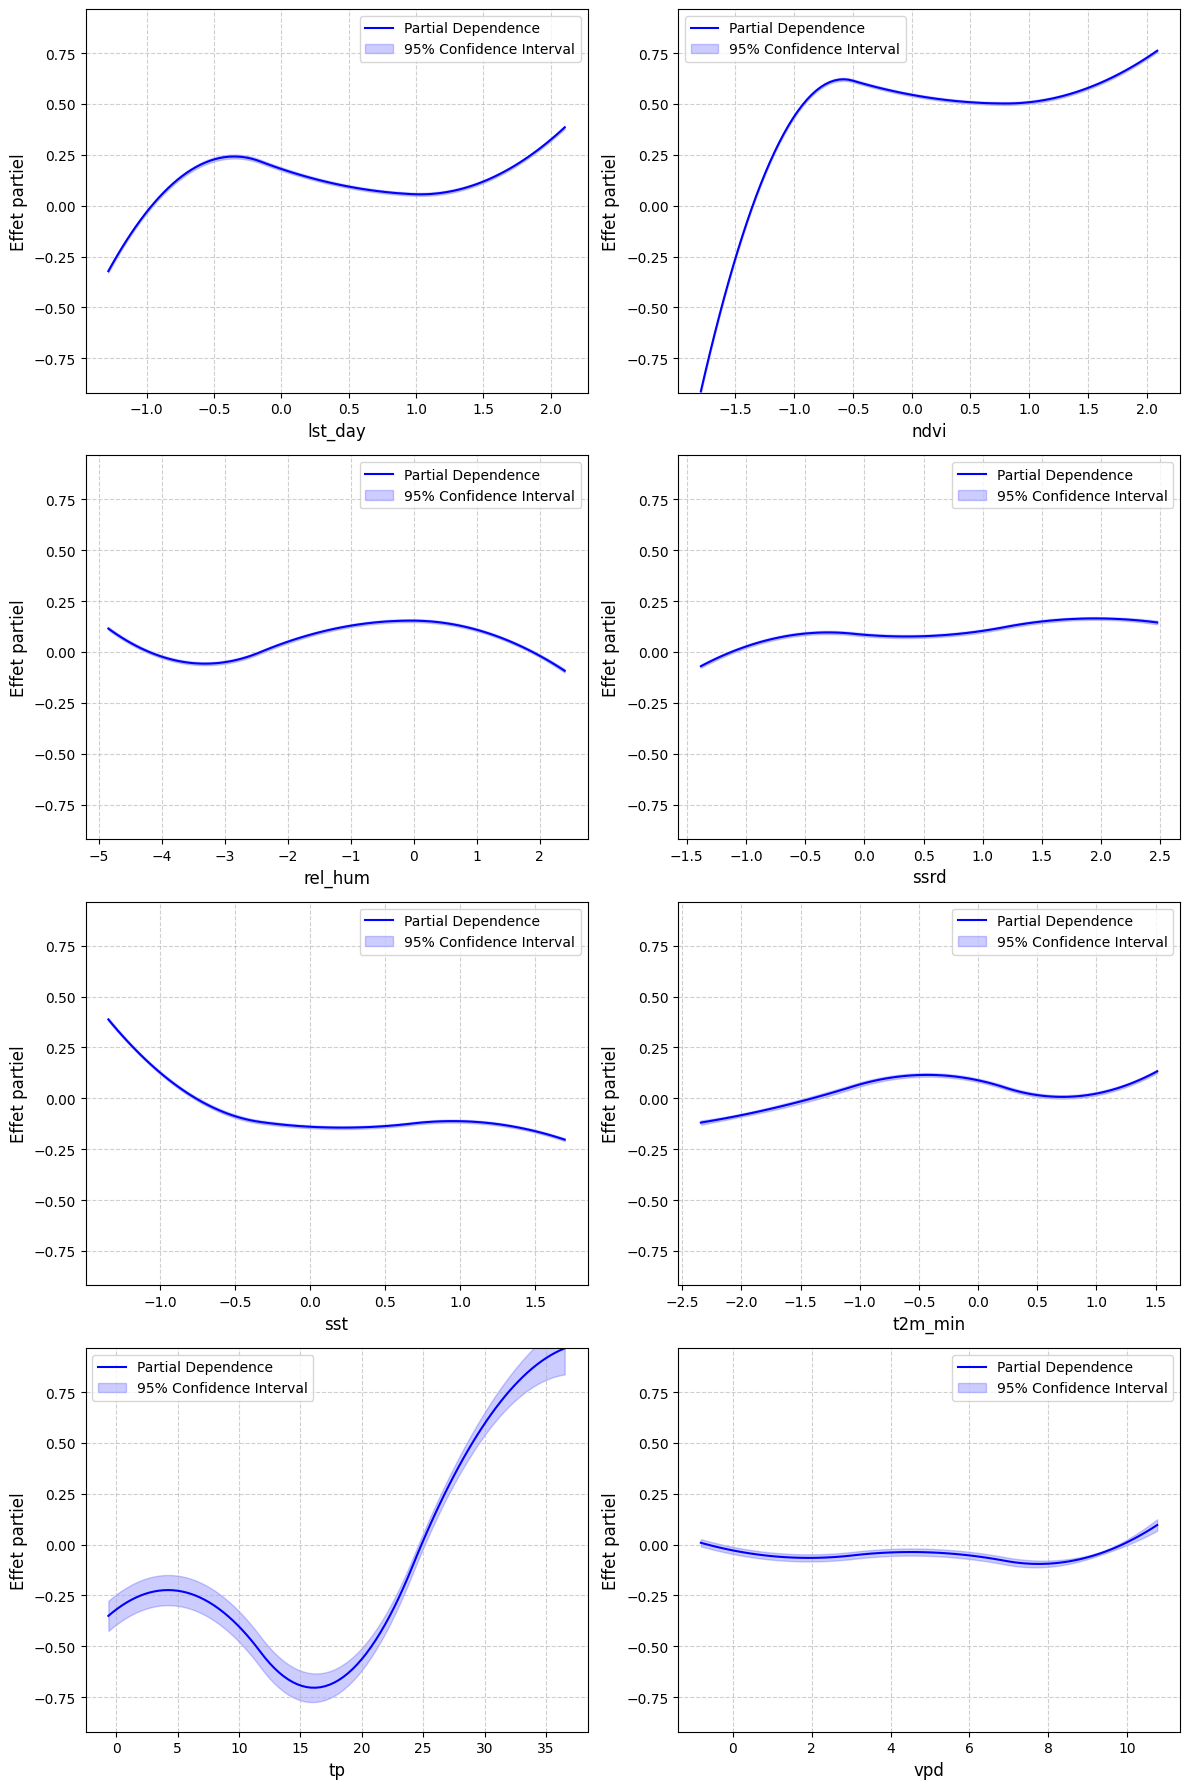

In [13]:
#open the saved GAM model
with open(f'gam_model_push_18.pkl', 'rb') as file:
    gam = pickle.load(file)

plot_effet_partiel(gam)

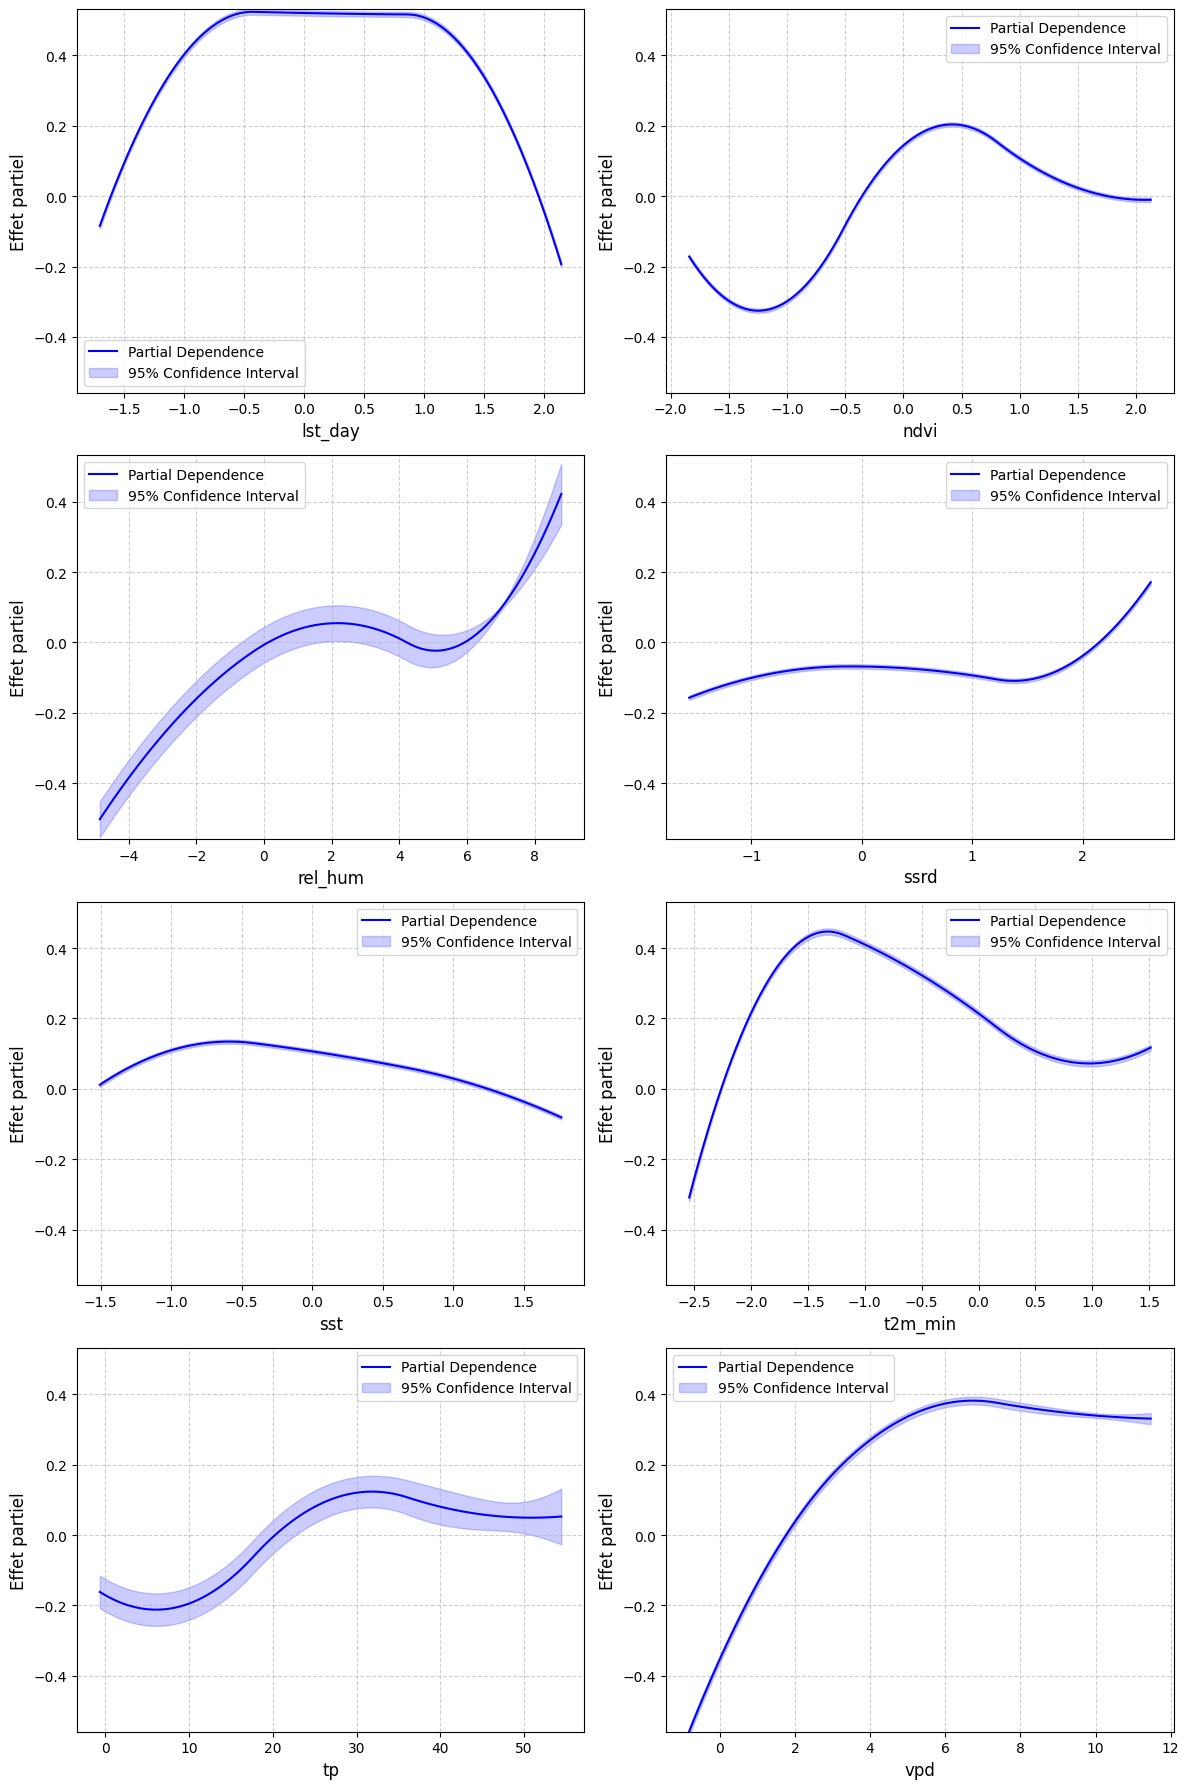

In [19]:
with open(f'gam_model_11.pkl', 'rb') as file:
    gam = pickle.load(file)

plot_effet_partiel(gam)